In [27]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
from array import array
import torch
import networkx as nx
from scipy.spatial import Delaunay
from torch_geometric.data import Data, Dataset
import sys
import os

In [28]:
#This notebook is mostly focused on building a more robust labeling system. Not as good as spine but better than what is currently in the AddInfo function in ClusterToGraph.
#Core idea from the ML group, semantic labels are hit-wise but do not need to be determined hit-wise. 
#Import needed files
DBSCAN_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2530.npz')
dbscan_hits = DBSCAN_file['first']

merged_hits_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/multihit/mulithit_detector_sim_lossy_2530.npz')
merged_hits_array = merged_hits_file['first']
n_neutrino_events = merged_hits_file['second']

f = root.TFile.Open("/sdf/data/neutrino/summer25/tanaka/nd-production/run-spill-build/MicroProdN4p1_NDComplex_FHC.spill.full/EDEPSIM_SPILLS/0002000/0002500/MicroProdN4p1_NDComplex_FHC.spill.full.0002530.EDEPSIM_SPILLS.root")
edep_events = f.Get("EDepSimEvents")
# Set the branch address.
event = root.TG4Event()
edep_events.SetBranchAddress("Event",root.AddressOf(event))
print("loaded")

loaded


In [29]:
#whole file statistics will be usefull in making threshold decisions:

#Generate a dictionary for the whole file at the top, more memory efficient 
nns_in_file = np.unique(dbscan_hits[:,0])
dbscan_file_dict = {} #holds the hit info dictionary for a given event. 
for nn in nns_in_file:
    event_merged_hits = merged_hits_array[merged_hits_array[:,0] == nn ]
    hit_numbers = event_merged_hits[:,1]
    edep_events.GetEntry(int(nn))
    event_hit_segments = event.SegmentDetectors['volTMS']
    trackid_dict = {} #stores hit number trackid pair. (hit # : trackid)
    
    for hit_number in hit_numbers:
        hit_segment = event_hit_segments[int(hit_number)]
        contrib_vector = hit_segment.Contrib
        trackid_dict[int(hit_number)] = contrib_vector[0] #just pulling trackid of first contributor to segment 

    pdgid_dict = {} #(trackid : pdgid)
    event_trajectories = event.Trajectories
    for trackid in trackid_dict.values():
        pdgid = event_trajectories[trackid].GetPDGCode()
        pdgid_dict[trackid] = pdgid

    #now create a different dictionary - call it info dict. looks like (hit # : (trackid, pdgid) ). 
    hit_info_dict = {}
    for hit_number in hit_numbers:
        hit_trackid = trackid_dict[hit_number]
        hit_pdgid = pdgid_dict[hit_trackid]
        hit_info_dict[int(hit_number)] = (hit_trackid, hit_pdgid)

    dbscan_file_dict[int(nn)] = hit_info_dict


#I would like to see a mask that categorizes by neutrino event that originated in the tms vs one that didn't. Not sure how useful this will be but could be interesting. 
edep_detsim = f.Get("DetSimPassThru") #grab detsim, should contain the gRooTracker
tracker_tree = edep_detsim.gRooTracker 

edep_true_neutrino_vtx = [] 
vtxs = array('d', [0.0]*5) 
tracker_tree.SetBranchAddress("EvtVtx", vtxs)
neutrino_vtxs_info = {}
for i in range(tracker_tree.GetEntries()):
    tracker_tree.GetEntry(i)
    #don't forget to scale positions (tracker inexplicably uses m)
    x = vtxs[0]*1000
    y = vtxs[1]*1000
    z = vtxs[2]*1000
    in_tms = 0 #default is not in the tms
    if (11185 <= z <= 18535): #check if in z range of tms
        if (-3730 <= x <= 3730): #check if in x range of tms (?)
            if (-2350 <= y <= 2350): #check if in y range of tms (?)
                in_tms = 1
    neutrino_vtxs_info[i] = (vtxs[0]*1000,vtxs[1]*1000,vtxs[2]*1000, in_tms) #x, y, z, in_tms (0 if false, 1 if true)



#a nest loop that gets down to the level of dbscan_cluster_level hits. 
dbscan_cluster_list = []
spills_in_file = np.unique(dbscan_hits[:,-4])
for spill_number in spills_in_file:
    spill_level = dbscan_hits[dbscan_hits[:,-4] == spill_number]
    segments_in_spill = np.unique(spill_level[:,-2])
    for segment_number in segments_in_spill:
        time_segment_level = spill_level[spill_level[:,-2] == segment_number]
        clusters_in_segment = np.unique(time_segment_level[:,-1])
        for cluster_number in clusters_in_segment:
            dbscan_cluster_level = time_segment_level[time_segment_level[:,-1] == cluster_number]
            rows = []
            for hit in dbscan_cluster_level:
                nn = hit[0]
                hn = hit[1]
                hit_info = (dbscan_file_dict[nn])[hn] #grabbing relevant hit information. 
                hit_trackid, hit_pdgid = hit_info
                in_tms = (neutrino_vtxs_info[int(nn)])[3]
                addition = np.array((hit_trackid, hit_pdgid, in_tms))
                new_row = np.hstack((hit, addition))
                rows.append(new_row)
    
            dbscan_hits_with_info = np.vstack(rows)
            dbscan_cluster_list.append(dbscan_hits_with_info)

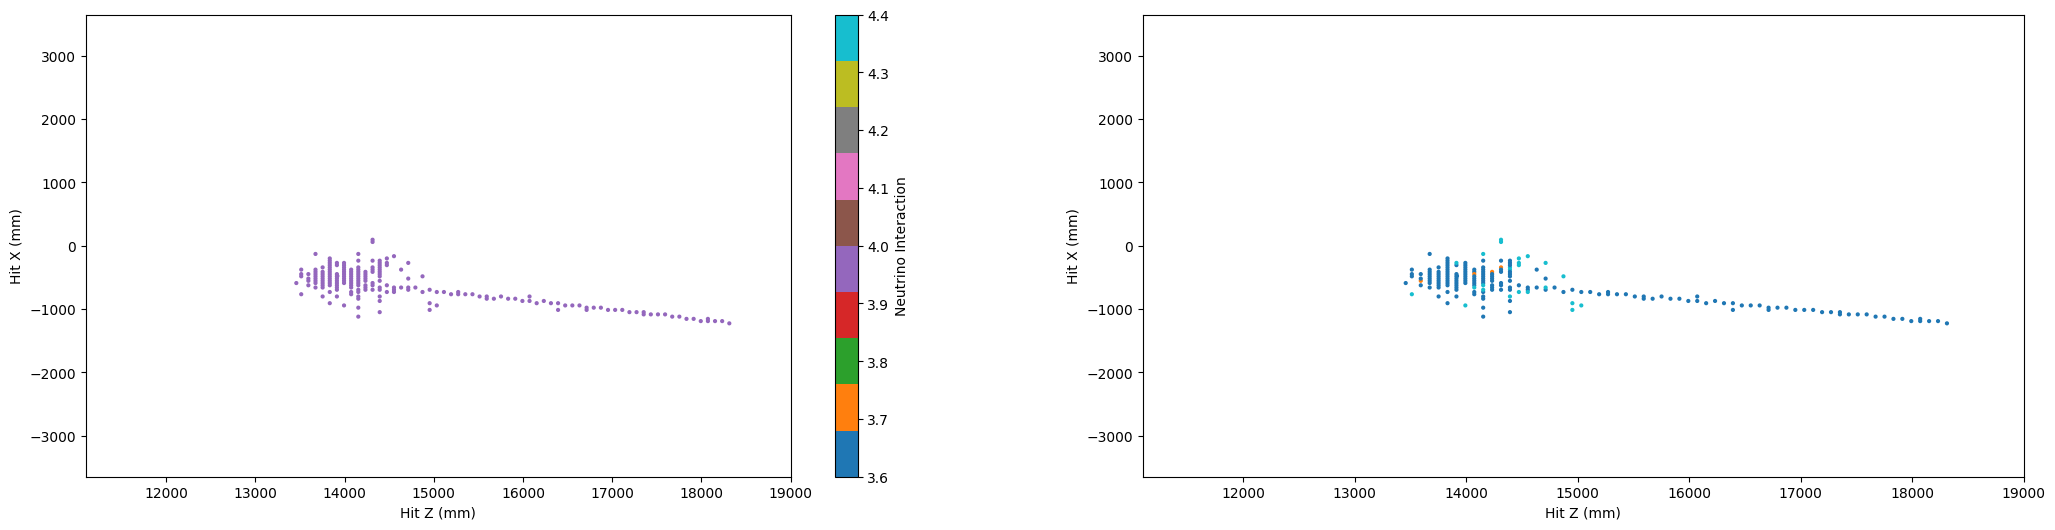

In [43]:
#There is utility in looking at stuff on a cluster by cluster basis. 
chosen_slice = 1
slice_hits = dbscan_cluster_list[chosen_slice]

hit_xs = slice_hits[:,2]
hit_zs = slice_hits[:,4]
hit_ts = slice_hits[:,5]
hit_PEs = slice_hits[:,6]
hit_nns = slice_hits[:,0]
hit_trackids = slice_hits[:,-3]
hit_pdgids = slice_hits[:,-2]
hit_tms_state = slice_hits[:,-1]

def hitcolor(pdgid):
    c = 'black' # black track by default
    if pdgid == 2212:
        c = 'red' # proton == red
    if pdgid == 2112:
        c = 'green' # neutron == green
    if pdgid == 211:
        c = 'magenta' # pi+ == magenta
    if pdgid == -211:
        c = 'cyan' # pi- == cyan
    if pdgid == 22:
        c = 'gold' # photon == gold
    if pdgid == 13:
        c = 'purple' # muon == purple
    if pdgid == -13:
        c = 'lightcoral' # anti-muon = coral
    if pdgid == 11:
        c = 'blue' # electron == blue
    if pdgid == -11:
        c = 'orange' # positron == orange
    return c    

hit_colors_by_pdgid = []
for pdgid_ in hit_pdgids:
    color = hitcolor(pdgid_)
    hit_colors_by_pdgid.append(color)

#A simple semantic mask, muons and all else. 
muon_semantic_mask = []
for pdgid_ in hit_pdgids:
    if pdgid_ == 13 or pdgid_ == -13:
        muon_semantic_mask.append('purple')
    else:
        muon_semantic_mask.append('black')

shower_semantic_mask = []
for pdgid_ in hit_pdgids:
    if pdgid_ == 11 or pdgid_ == -11 or pdgid_ == 22:
        shower_semantic_mask.append('red')
    else:
        shower_semantic_mask.append('black')

in_tms_mask = []
for state in hit_tms_state:
    if state == 1:
        in_tms_mask.append('green')
    else:
        in_tms_mask.append('black')

combined_semantic_mask = []
for i in range(len(hit_tms_state)):
    if (hit_pdgids[i] == 13 or hit_pdgids[i] == -13): #muon or antimuon?
        if hit_tms_state[i] == 1: 
            combined_semantic_mask.append('purple') #muon from interaction in TMS
        else:
            combined_semantic_mask.append('blue') #muon from interaction outside of the TMS
    else:
        if hit_tms_state[i] == 1: 
            combined_semantic_mask.append('red') #other from interaction in TMS
        else:
            combined_semantic_mask.append('green') #other from interaction outside of the TMS 
        



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 6))

sc1 = ax1.scatter(hit_zs, hit_xs, s = 4, c = hit_nns , cmap = 'tab10')
fig.colorbar(sc1, ax=ax1, label = 'Neutrino Interaction')
#ax1.set_title(f"Cluster {cluster_number} Time Segment {time_segment_number}, Spill {spill_number}")
ax1.set_xlim((11100,19000))
ax1.set_ylim((-3650,3650))
ax1.set_xlabel("Hit Z (mm)")
ax1.set_ylabel("Hit X (mm)")

sc2 = ax2.scatter(hit_zs, hit_xs, s = 4, c = hit_pdgids, cmap = 'tab10')
#ax2.set_title(f"Cluster {cluster_number} Time Segment {time_segment_number}, Spill {spill_number}")
ax2.set_xlim((11100,19000))
ax2.set_ylim((-3650,3650))
ax2.set_xlabel("Hit Z (mm)")
ax2.set_ylabel("Hit X (mm)")

xlims = ax1.get_xlim()
ylims = ax1.get_ylim()

In [31]:
#single cluster split. This is done based purely off pdgid
muon_track_groups = []
other_track_groups = []
trackid_separated = []
for nn in np.unique(slice_hits[:,0]):
    nn_sub_array = slice_hits[slice_hits[:,0] == nn]
    for trackid in np.unique(nn_sub_array[:,-3]):
        trackid_sub_array = nn_sub_array[nn_sub_array[:,-3] == trackid]
        track_group_particle = np.unique(trackid_sub_array[:,-2])[0]
        trackid_separated.append(trackid_sub_array)
        if (track_group_particle == 13 or track_group_particle == -13): #grab the track groups with muon hits. 
            muon_track_groups.append(trackid_sub_array)
            
        else: #grab all the other track groups.
            other_track_groups.append(trackid_sub_array)

In [32]:
basic_tracks = []
basic_showers = []
for trackid_group in trackid_separated:
    if np.shape(trackid_group)[0] > 4:
        basic_tracks.append(trackid_group)
    else:
        basic_showers.append(trackid_group)

#create primary track list!
primary_track_list = []
for track_group in basic_tracks:
    primary_track_list.append( (int(track_group[0][0]), int(track_group[0][-3])) )

In [33]:
advanced_tracks = basic_tracks
advanced_showers = []
for group in basic_showers:
    nn = group[0][0] #grab neutrino # for group
    trackid = group[0][-3] #grab the trackid for the group
    #now quickly grab the trackids of our primary track groups associated w/this event, for use
    edep_events.GetEntry(int(nn))
    event_trajectories = event.Trajectories #fetch trajectories vector
    group_traj = event_trajectories[int(trackid)] #our root trajectory 
    group_traj_parent = group_traj.GetParentId()
    group_traj_grandparent = event_trajectories[int(group_traj_parent)].GetParentId()
    parent_tuple_reference = (int(nn), int(group_traj_parent))
    grandparent_tuple_reference = (int(nn), int(group_traj_grandparent))
    added = False
    for i, ptref in enumerate(primary_track_list): #i will key which index of the track list to add to. 
        #check first if the parent matches
        if ptref == parent_tuple_reference:
            #print('found a shower w/ a main track parent')
            #print(f'{parent_tuple_reference} and {ptref}')
            advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
            added = True
        #if not, check if the grandparent matches, to expand tracks even further. 
        elif ptref == grandparent_tuple_reference:
            advanced_tracks[i] = (np.vstack((basic_tracks[i], group)) )
            added = True
    if added == False:
        advanced_showers.append(group)


In [34]:
advanced_tracks_array = np.vstack(advanced_tracks)
advanced_showers_array = np.vstack(advanced_showers)

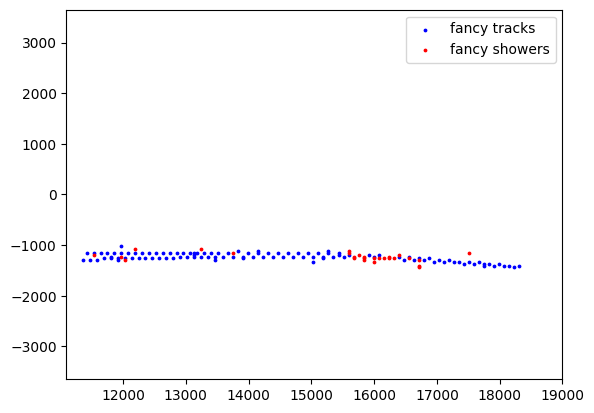

In [35]:
plt.scatter(advanced_tracks_array[:,4], advanced_tracks_array[:,2], c = 'blue', label = 'fancy tracks', s = 3)

plt.scatter(advanced_showers_array[:,4], advanced_showers_array[:,2], c = 'red', label = 'fancy showers', s =3)
plt.xlim(xlims)
plt.ylim(ylims)
plt.legend()

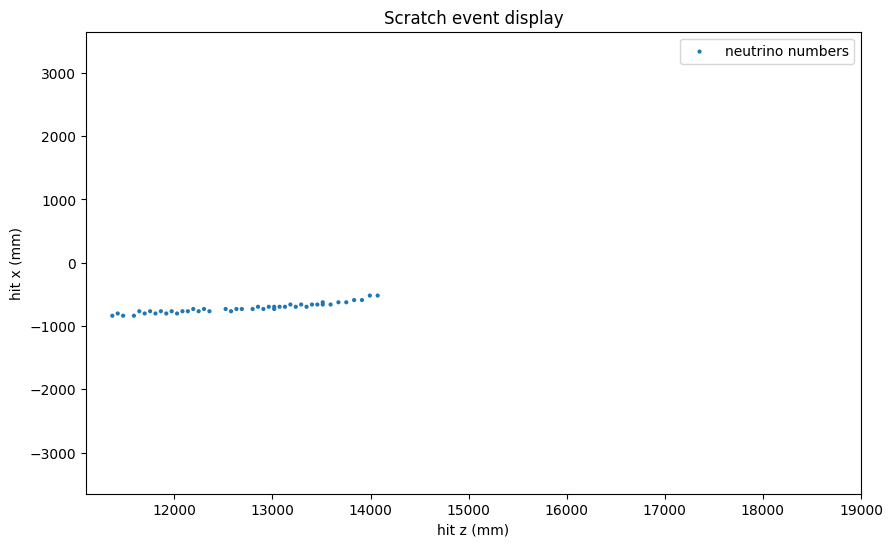

In [88]:
#scratch display muons other_track_groups
track_group_index = 0
hit_xs = muon_track_groups[track_group_index][:,2]
hit_zs = muon_track_groups[track_group_index][:,4]
hit_ts = muon_track_groups[track_group_index][:,5]
hit_nns = muon_track_groups[track_group_index][:,0]
plt.scatter(hit_zs, hit_xs, s = 4, c = hit_nns, cmap = 'tab10', label = "neutrino numbers")
plt.xlabel("hit z (mm)")
plt.ylabel("hit x (mm)")
plt.xlim(xlims)
plt.ylim(ylims)
plt.title(f"Scratch event display")
plt.legend()
plt.show()

In [11]:
#Interested in what the full file split looks like for muons vs nonmuons:
file_muon_track_groups = []
file_other_track_groups = []
file_trackid_separated = []

for i in range(len(dbscan_cluster_list)):
    slice_hits = dbscan_cluster_list[i]
    for nn in np.unique(slice_hits[:,0]):
        nn_sub_array = slice_hits[slice_hits[:,0] == nn]
        for trackid in np.unique(nn_sub_array[:,-3]):
            trackid_sub_array = nn_sub_array[nn_sub_array[:,-3] == trackid]
            trackid_separated.append(trackid_sub_array)
            track_group_particle = np.unique(trackid_sub_array[:,-2])[0]
            if (track_group_particle == 13 or track_group_particle == -13): #grab the track groups with muon hits. 
                file_muon_track_groups.append(trackid_sub_array)
            
            else: #grab all the other track groups.
                file_other_track_groups.append(trackid_sub_array)

In [9]:
track_lengths = []
pdgids = []

for track in file_other_track_groups:
    pdgids.append(track[0][-2])
    track_lengths.append(np.shape(track)[0])

for track in file_muon_track_groups:
    pdgids.append(track[0][-2])
    track_lengths.append(np.shape(track)[0])

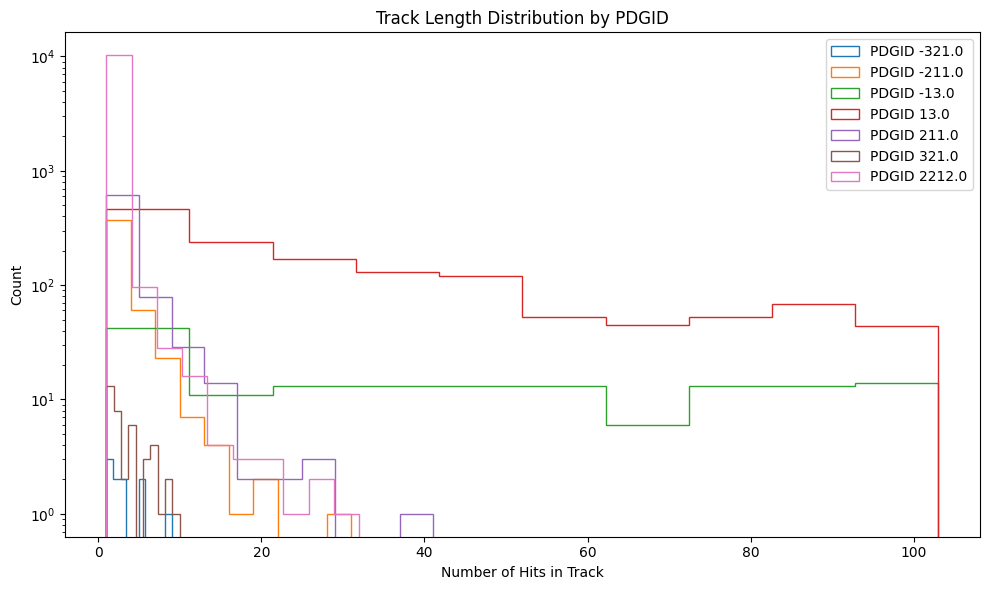

In [10]:
plt.rcParams['figure.figsize'] = (10, 6)
track_length_array = np.column_stack((pdgids,track_lengths))
unique_pdgids = np.unique(track_length_array[:,0])
for pdgid in unique_pdgids:
    if pdgid == 2212 or abs(pdgid) == 321 or abs(pdgid) == 211 or abs(pdgid) == 13 : #if abs(pdgid) < 10000 and abs(pdgid) > 50: #don't really care about nuclei
        sub_array = track_length_array[track_length_array[:,0] == pdgid]
        plt.hist(sub_array[:,1], bins = 10, label=f"PDGID {pdgid}", histtype = 'step')

plt.xlabel("Number of Hits in Track")
plt.ylabel("Count")
plt.yscale("log")
plt.title("Track Length Distribution by PDGID")
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
dists = []
number_of_hits = []
for track in file_other_track_groups:
    n_hits = np.shape(track)[0]
    x_range = max(track[:,2]) - min(track[:,2])
    z_range = max(track[:,4]) - min(track[:,4])
    dist = np.sqrt(x_range**2 + z_range**2)
    dists.append(dist)
    number_of_hits.append(n_hits)

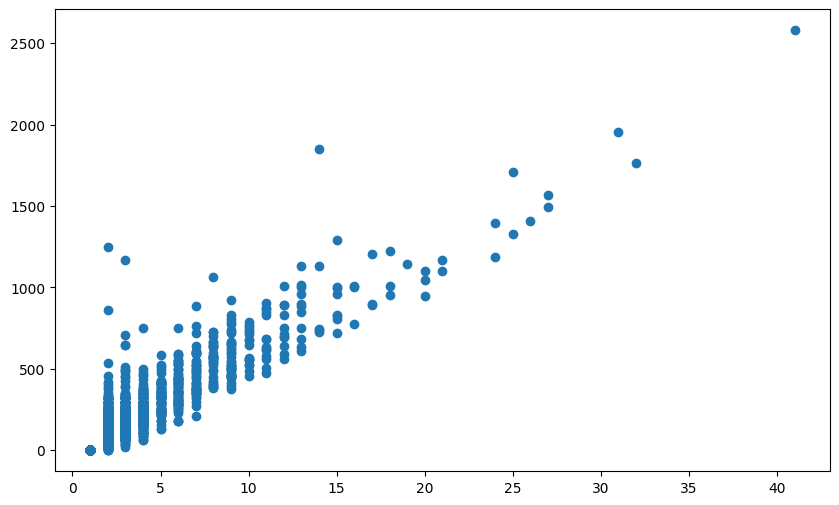

In [53]:
plt.scatter(number_of_hits, dists)